# 8.5k Steps: No Quaternions (D1 Experiment)

Tests Phase D1 from `results/2026-03-10/architecture_log.md`: drop quaternion dimensions
and see if the diffusion model can learn the remaining 11-dim state space.

**Hypothesis:** Quaternions (unit-norm, antipodal symmetry) are geometrically hostile to
L2 diffusion. Dropping them reduces state dim from 19 → 11 and transition dim from 26 → 18.
The reward function only depends on cube_z (index 2), which is unaffected.

**Changes from `8.5k_steps.ipynb`:**

| Parameter | 8.5k baseline | This notebook |
|-----------|--------------|---------------|
| State dim | 19 | 11 (drop 8 quat dims) |
| Transition dim | 26 | 18 |
| dim_mults | (1, 2) | (1, 2) |
| Training | 500 epochs × 17 batches = 8,500 steps | Same |
| Everything else | Same | Same |

**Dropped dimensions:**
- Indices 3–6: `object` quaternion (cube_qw, cube_qx, cube_qy, cube_qz)
- Indices 13–16: `robot0_eef_quat` (eef_qw, eef_qx, eef_qy, eef_qz)

**Kept dimensions (new layout):**

| New Index | Old Index | Content |
|-----------|-----------|----------|
| 0–2 | 0–2 | cube_pos (x, y, z) |
| 3–5 | 7–9 | gripper_to_cube (x, y, z) |
| 6–8 | 10–12 | eef_pos (x, y, z) |
| 9–10 | 17–18 | gripper_qpos (0, 1) |

## Setup

In [5]:
%load_ext autoreload
%autoreload 2

import sys
import tempfile
import shutil
from pathlib import Path

import numpy as np
import h5py
import torch

REPO_ROOT = Path("../../").resolve()
sys.path.insert(0, str(REPO_ROOT))

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"Repo root: {REPO_ROOT}")

# --- Common paths ---
POLICY_DIR = REPO_ROOT / "third_party" / "robomimic" / "diffusion_policy_trained_models" / "test"
policy_train_dirs = sorted([d for d in POLICY_DIR.glob("*") if d.is_dir()])
assert len(policy_train_dirs) > 0, "No trained policies found."
policy_train_dir = policy_train_dirs[-1]
print(f"Using policy from: {policy_train_dir}")

# --- Hyperparams ---
K = 50
N_ROLLOUTS = 50
EPOCHS = 500
HORIZON = 60
gamma = 1.0
BATCH_SIZE = 64
NUM_TRAJS = 50

CHECKPOINT_EPOCHS = [50, 100, 200, 500]

# --- Quaternion removal config ---
# Full 19-dim layout: obj_pos(3) obj_quat(4) g2c(3) eef_pos(3) eef_quat(4) grip(2)
# Keep: obj_pos(0-2), g2c(7-9), eef_pos(10-12), grip(17-18)
KEEP_INDICES = [0, 1, 2, 7, 8, 9, 10, 11, 12, 17, 18]
REDUCED_STATE_DIM = len(KEEP_INDICES)  # 11

# New layout dimension labels
DIM_LABELS = [
    "obj_px", "obj_py", "obj_pz",
    "g2c_x", "g2c_y", "g2c_z",
    "eef_px", "eef_py", "eef_pz",
    "grip_0", "grip_1",
]

# Key dimension indices in the NEW reduced layout
CUBE_Z_IDX = 2      # cube z-position (reward signal)
EEF_Z_IDX = 8       # end-effector z-position
CUBE_X_IDX = 0      # cube x-position
EEF_X_IDX = 6       # end-effector x-position

print(f"Dropping quaternion dims: 19 → {REDUCED_STATE_DIM} state dims")
print(f"Transition dim: {REDUCED_STATE_DIM + 7} (was 26)")
print(f"Keep indices: {KEEP_INDICES}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Device: cuda
Repo root: /home1/reishuen/latent_sope
Using policy from: /home1/reishuen/latent_sope/third_party/robomimic/diffusion_policy_trained_models/test/20260309132349
Dropping quaternion dims: 19 → 11 state dims
Transition dim: 18 (was 26)
Keep indices: [0, 1, 2, 7, 8, 9, 10, 11, 12, 17, 18]


## Step 0: Oracle (cached, unchanged)

In [6]:
import json

from src.latent_sope.robomimic_interface.checkpoints import load_checkpoint
from src.latent_sope.eval.oracle import oracle_value as compute_oracle_value, save_oracle_result, load_oracle_result

oracle_path = policy_train_dir / "oracle_50.json"
assert oracle_path.exists(), f"Oracle cache not found at {oracle_path}"

oracle_result = load_oracle_result(oracle_path)
oracle_value = oracle_result.mean_return
oracle_returns = oracle_result.returns.tolist()
print(f"Oracle V^pi = {oracle_value:.3f} (std={np.std(oracle_returns):.3f}, K={len(oracle_returns)})")

Oracle V^pi = 0.540 (std=0.498, K=50)


## Step 1: Load Offline Data & Strip Quaternions

Load the cached 19-dim rollouts, strip quaternion dimensions (indices 3-6, 13-16),
and save 11-dim versions to a temp directory so the standard dataloader can consume them.

In [7]:
from src.latent_sope.robomimic_interface.rollout import (
    load_rollout_latents,
)

# Load original rollouts
output_dir = policy_train_dir / "rollout_latents_50"
existing_rollouts = sorted(output_dir.glob("*.h5"))
assert len(existing_rollouts) >= N_ROLLOUTS
original_paths = existing_rollouts[:N_ROLLOUTS]

# Create filtered rollouts in a persistent directory (not temp, so notebook re-runs work)
filtered_dir = policy_train_dir / "rollout_latents_50_no_quat"
filtered_dir.mkdir(exist_ok=True)

rollout_paths = []
for src_path in original_paths:
    dst_path = filtered_dir / src_path.name
    if dst_path.exists():
        rollout_paths.append(dst_path)
        continue

    # Load, filter, save
    with h5py.File(str(src_path), "r") as f_in:
        latents_full = np.asarray(f_in["latents"], dtype=np.float32)
        actions = np.asarray(f_in["actions"], dtype=np.float32)
        rewards = np.asarray(f_in["rewards"], dtype=np.float32)
        dones = np.asarray(f_in["dones"])
        attrs = dict(f_in.attrs)

    # Strip quaternion dims
    if latents_full.ndim == 3:
        # (T, frame_stack, 19) → (T, frame_stack, 11)
        latents_reduced = latents_full[:, :, KEEP_INDICES]
    else:
        # (T, 19) → (T, 11)
        latents_reduced = latents_full[:, KEEP_INDICES]

    with h5py.File(str(dst_path), "w") as f_out:
        f_out.create_dataset("latents", data=latents_reduced, compression="gzip")
        f_out.create_dataset("actions", data=actions, compression="gzip")
        f_out.create_dataset("rewards", data=rewards, compression="gzip")
        f_out.create_dataset("dones", data=dones, compression="gzip")
        for k, v in attrs.items():
            f_out.attrs[k] = v

    rollout_paths.append(dst_path)

# Verify
sample_traj = load_rollout_latents(rollout_paths[0])
print(f"Filtered rollouts saved to: {filtered_dir}")
print(f"Original latent shape: {latents_full.shape}")
print(f"Reduced latent shape:  {sample_traj.latents.shape}")
print(f"Actions shape:         {sample_traj.actions.shape}")

# Sanity: cube z should be the same
with h5py.File(str(original_paths[0]), "r") as f:
    orig_latents = np.asarray(f["latents"], dtype=np.float32)
if orig_latents.ndim == 3:
    orig_cube_z = orig_latents[:, 0, 2]
else:
    orig_cube_z = orig_latents[:, 2]

reduced_latents = sample_traj.latents
if reduced_latents.ndim == 3:
    reduced_cube_z = reduced_latents[:, 0, CUBE_Z_IDX]
else:
    reduced_cube_z = reduced_latents[:, CUBE_Z_IDX]

assert np.allclose(orig_cube_z, reduced_cube_z), "Cube z mismatch after filtering!"
print(f"Cube z sanity check PASSED (index {CUBE_Z_IDX} in reduced = index 2 in original)")

Filtered rollouts saved to: /home1/reishuen/latent_sope/third_party/robomimic/diffusion_policy_trained_models/test/20260309132349/rollout_latents_50_no_quat


NameError: name 'latents_full' is not defined

## Step 2: Chunk the Filtered Data

In [8]:
from src.latent_sope.robomimic_interface.dataset import (
    RolloutChunkDatasetConfig,
    make_rollout_chunk_dataloader,
)

latents_dim = sample_traj.latents.shape[-1]  # 11
action_dim = sample_traj.actions.shape[-1]    # 7
print(f"Latent dim: {latents_dim}, Action dim: {action_dim}")
assert latents_dim == REDUCED_STATE_DIM, f"Expected {REDUCED_STATE_DIM}, got {latents_dim}"

dataset_config = RolloutChunkDatasetConfig(
    chunk_size=8,
    stride=2,
    frame_stack=2,
    source="latents",
    latents_dim=latents_dim,
    action_dim=action_dim,
    normalize=True,
    return_metadata=True,
)

dataloader, norm_stats = make_rollout_chunk_dataloader(
    paths=rollout_paths,
    config=dataset_config,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
)

n_batches = len(dataloader)
total_steps = n_batches * EPOCHS
print(f"DataLoader: {n_batches} batches of size {BATCH_SIZE}")
print(f"Total gradient steps over {EPOCHS} epochs: {total_steps}")
print(f"Normalization stats: mean shape={norm_stats.mean.shape}")
print(f"  mean = {norm_stats.mean}")
print(f"  std  = {norm_stats.std}")

Latent dim: 11, Action dim: 7
DataLoader: 17 batches of size 64
Total gradient steps over 500 epochs: 8500
Normalization stats: mean shape=(18,)
  mean = [ 0.00411157  0.00353075  0.82086724  0.01623373  0.00235265 -0.08289479
 -0.01212199  0.00117815  0.9037655   0.03394671 -0.03414056  0.15932705
 -0.00203455 -0.23222315  0.00211767 -0.01426005 -0.02716194 -0.5802205 ]
  std  = [0.01698436 0.01602272 0.00148859 0.03559378 0.01136428 0.05524012
 0.03545026 0.01587915 0.05531172 0.00948154 0.00938271 0.22440748
 0.09708639 0.37735242 0.0187077  0.04148198 0.06577061 0.80434537]


## Step 3: Train (same config as 8.5k baseline, but 11-dim states)

In [9]:
from tqdm.auto import tqdm
from dataclasses import asdict
import matplotlib.pyplot as plt
from src.latent_sope.diffusion.sope_diffuser import (
    SopeDiffusionConfig,
    SopeDiffuser,
    NormalizationStats as DiffusionNormStats,
    cross_validate_configs,
)

ckpt_dir = policy_train_dir / "diffusion_ckpts_no_quat_8.5k"
ckpt_dir.mkdir(exist_ok=True)

diffusion_config = SopeDiffusionConfig(
    chunk_horizon=dataset_config.chunk_size,   # 8
    frame_stack=dataset_config.frame_stack,     # 2
    state_dim=latents_dim,                      # 11
    action_dim=action_dim,                      # 7
    diffusion_steps=256,
    dim_mults=(1, 2),                           # Same as 8.5k baseline
    attention=False,
    loss_type="l2",
    action_weight=5.0,
    predict_epsilon=True,
    lr=3e-4,
    guided=False,
)

cross_validate_configs(dataset_config, diffusion_config)
print(f"Config cross-validation passed. total_horizon={diffusion_config.total_chunk_horizon}")
print(f"transition_dim = {latents_dim + action_dim} (was 26, now {latents_dim + action_dim})")

diff_norm_stats = None
if norm_stats is not None:
    diff_norm_stats = DiffusionNormStats(mean=norm_stats.mean, std=norm_stats.std)

diffuser = SopeDiffuser(cfg=diffusion_config, normalization_stats=diff_norm_stats, device=device)
optimizer = diffuser.make_optimizer()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=2 * EPOCHS)

n_params = sum(p.numel() for p in diffuser.diffusion.parameters())
print(f"TemporalUnet parameters: {n_params:,}")
print(f"Training for {EPOCHS} epochs (~{n_batches * EPOCHS} gradient steps)")
print(f"Checkpoints at epochs: {CHECKPOINT_EPOCHS}")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Config cross-validation passed. total_horizon=10
transition_dim = 18 (was 26, now 18)
[ models/temporal ] Channel dimensions: [(18, 32), (32, 64)]
[(18, 32), (32, 64)]
TemporalUnet parameters: 250,898
Training for 500 epochs (~8500 gradient steps)
Checkpoints at epochs: [50, 100, 200, 500]


/home1/reishuen/latent_sope/third_party/sope/opelab/core/baselines/diffusion/diffusion.py:314: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  betas * np.sqrt(alphas_cumprod_prev) / (1. - alphas_cumprod))


In [10]:
# --- Training loop ---
GRAD_CLIP = 1.0
all_losses = []
epoch_mean_losses = []
lr_history = []

diffuser.diffusion.train()

for epoch in range(1, EPOCHS + 1):
    epoch_losses = []
    for batch in tqdm(dataloader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False):
        batch_dev = {
            k: v.to(device) if isinstance(v, torch.Tensor) else v
            for k, v in batch.items()
        }
        loss, info = diffuser.loss(batch_dev)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(diffuser.diffusion.parameters(), GRAD_CLIP)
        optimizer.step()
        all_losses.append(loss.item())
        epoch_losses.append(loss.item())

    scheduler.step()
    mean_loss = np.mean(epoch_losses)
    epoch_mean_losses.append(mean_loss)
    lr_history.append(scheduler.get_last_lr()[0])

    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d}: mean loss = {mean_loss:.6f}, lr = {lr_history[-1]:.2e}")

    if epoch in CHECKPOINT_EPOCHS:
        ckpt_payload = {
            "diffusion_state_dict": diffuser.diffusion.state_dict(),
            "epoch": epoch,
            "step": len(all_losses),
            "mean_loss": mean_loss,
            "diffusion_config": asdict(diffusion_config),
            "dataset_config": asdict(dataset_config),
            "normalization_stats": {
                "mean": norm_stats.mean, "std": norm_stats.std,
            } if norm_stats is not None else None,
            "keep_indices": KEEP_INDICES,
        }
        save_path = ckpt_dir / f"sope_diffuser_epoch_{epoch:04d}.pt"
        torch.save(ckpt_payload, str(save_path))
        print(f"  -> Saved checkpoint to {save_path.name}")

# Save latest
ckpt_payload["epoch"] = EPOCHS
ckpt_payload["step"] = len(all_losses)
ckpt_payload["mean_loss"] = epoch_mean_losses[-1]
torch.save(ckpt_payload, str(ckpt_dir / "sope_diffuser_latest.pt"))
print(f"\nTraining complete. Final loss: {epoch_mean_losses[-1]:.6f}")
print(f"Total gradient steps: {len(all_losses)}")

Epoch 1/500:   0%|          | 0/17 [00:00<?, ?it/s]

Epoch    1: mean loss = 1.382736, lr = 3.00e-04


Epoch 2/500:   0%|          | 0/17 [00:00<?, ?it/s]

Epoch 3/500:   0%|          | 0/17 [00:00<?, ?it/s]

Epoch 4/500:   0%|          | 0/17 [00:00<?, ?it/s]

...

Epoch 497/500:   0%|          | 0/17 [00:00<?, ?it/s]

Epoch 498/500:   0%|          | 0/17 [00:00<?, ?it/s]

Epoch 499/500:   0%|          | 0/17 [00:00<?, ?it/s]

Epoch 500/500:   0%|          | 0/17 [00:00<?, ?it/s]

Epoch  500: mean loss = 0.566739, lr = 1.50e-04
  -> Saved checkpoint to sope_diffuser_epoch_0500.pt

Training complete. Final loss: 0.566739
Total gradient steps: 8500


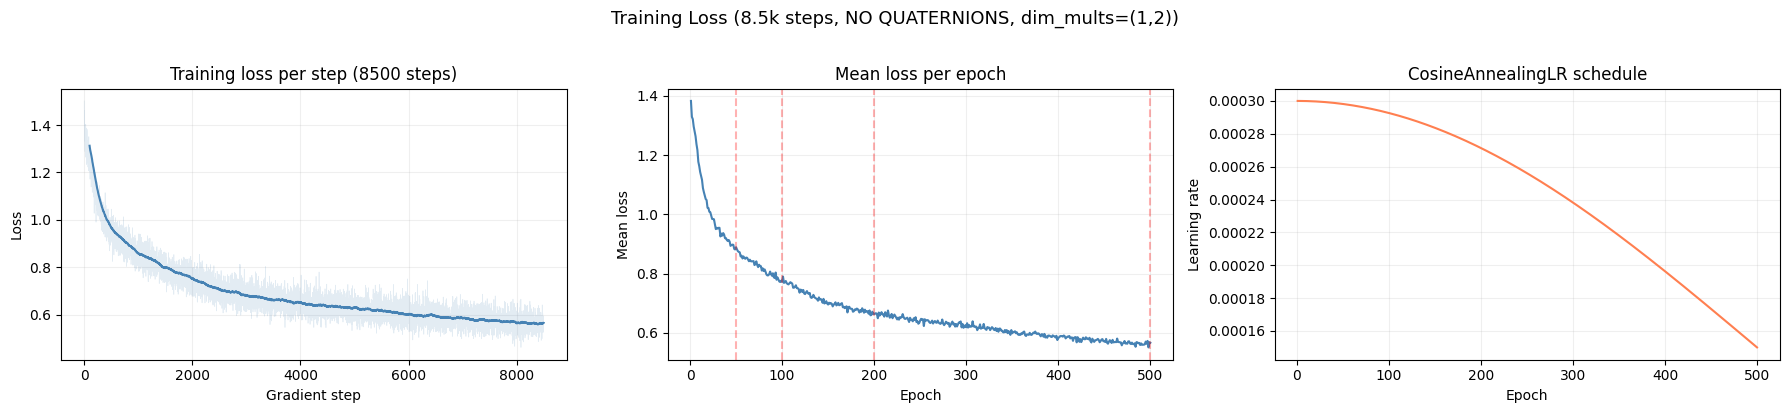


Convergence check:
  First 10% epochs mean loss:  1.030141
  Last 10% epochs mean loss:   0.566669
  Ratio (last/first):          0.5501


In [11]:
# --- Loss curve analysis ---
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

ax = axes[0]
ax.plot(all_losses, alpha=0.15, color="steelblue", linewidth=0.5)
window = min(100, max(1, len(all_losses) // 10))
if window > 1:
    smoothed = np.convolve(all_losses, np.ones(window) / window, mode="valid")
    ax.plot(range(window - 1, len(all_losses)), smoothed, color="steelblue", linewidth=1.5)
ax.set_xlabel("Gradient step")
ax.set_ylabel("Loss")
ax.set_title(f"Training loss per step ({len(all_losses)} steps)")
ax.grid(alpha=0.2)

ax = axes[1]
ax.plot(range(1, EPOCHS + 1), epoch_mean_losses, color="steelblue", linewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean loss")
ax.set_title("Mean loss per epoch")
ax.grid(alpha=0.2)
for ep in CHECKPOINT_EPOCHS:
    if ep <= len(epoch_mean_losses):
        ax.axvline(ep, color="red", alpha=0.3, linestyle="--")

ax = axes[2]
ax.plot(range(1, EPOCHS + 1), lr_history, color="coral", linewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning rate")
ax.set_title("CosineAnnealingLR schedule")
ax.grid(alpha=0.2)

fig.suptitle("Training Loss (8.5k steps, NO QUATERNIONS, dim_mults=(1,2))", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

last_10pct = epoch_mean_losses[int(0.9 * EPOCHS):]
first_10pct = epoch_mean_losses[:int(0.1 * EPOCHS)]
print(f"\nConvergence check:")
print(f"  First 10% epochs mean loss:  {np.mean(first_10pct):.6f}")
print(f"  Last 10% epochs mean loss:   {np.mean(last_10pct):.6f}")
print(f"  Ratio (last/first):          {np.mean(last_10pct) / np.mean(first_10pct):.4f}")

## Chunk Quality at Each Checkpoint

**Target:** L2 < 1.0. Compare directly to 8.5k baseline (L2 = 7287 with quaternions).

In [12]:
from src.latent_sope.eval.metrics import l2_chunk_error

test_batch = next(iter(dataloader))
test_batch_dev = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in test_batch.items()}

cat_sf = torch.cat([test_batch_dev["states_from"], test_batch_dev["actions_from"]], dim=-1)
cat_st = torch.cat([test_batch_dev["states_to"][:, :-1, :], test_batch_dev["actions_to"]], dim=-1)
x_gt = torch.cat([cat_sf, cat_st], dim=1)
cond = diffuser.make_cond(test_batch_dev)

state_dim = diffuser.state_dim
chunk_results = {}

for ckpt_epoch in CHECKPOINT_EPOCHS:
    ckpt_file = ckpt_dir / f"sope_diffuser_epoch_{ckpt_epoch:04d}.pt"
    if not ckpt_file.exists():
        print(f"Checkpoint epoch {ckpt_epoch} not found, skipping.")
        continue

    payload = torch.load(str(ckpt_file), map_location=device, weights_only=False)
    diffuser.diffusion.load_state_dict(payload["diffusion_state_dict"])
    diffuser.diffusion.eval()

    with torch.no_grad():
        sample = diffuser.diffusion.conditional_sample(
            shape=x_gt.shape, cond=cond, guided=False, verbose=False,
        )
    x_hat = sample.trajectories

    x_gt_unnorm = diffuser.unnormalizer(x_gt).cpu().numpy()
    x_hat_unnorm = diffuser.unnormalizer(x_hat).cpu().numpy()

    err_s = l2_chunk_error(x_hat_unnorm[:, :, :state_dim], x_gt_unnorm[:, :, :state_dim])
    err_a = l2_chunk_error(x_hat_unnorm[:, :, state_dim:], x_gt_unnorm[:, :, state_dim:])

    chunk_results[ckpt_epoch] = {
        "state_l2": err_s.mean_l2,
        "state_l2_std": err_s.std_l2,
        "action_l2": err_a.mean_l2,
        "action_l2_std": err_a.std_l2,
        "rmse_per_dim": err_s.rmse_per_dim,
    }
    print(f"Epoch {ckpt_epoch:4d}: state L2 = {err_s.mean_l2:.4f} ± {err_s.std_l2:.4f}, "
          f"action L2 = {err_a.mean_l2:.4f} ± {err_a.std_l2:.4f}")

# Reload final
best_epoch = CHECKPOINT_EPOCHS[-1]
payload = torch.load(str(ckpt_dir / f"sope_diffuser_epoch_{best_epoch:04d}.pt"), map_location=device, weights_only=False)
diffuser.diffusion.load_state_dict(payload["diffusion_state_dict"])
diffuser.diffusion.eval()
print(f"\nLoaded epoch {best_epoch} for subsequent steps.")


                                                                                                    
1 / 256 [                                                            ]   0% | 19.7 Hz
t : 255
                                                                                                    
                                                                                                    
2 / 256 [                                                            ]   0% | 35.4 Hz
t : 254
                                                                                                    
                                                                                                    
3 / 256 [                                                            ]   1% | 49.0 Hz
t : 253
                                                                                                    
                                                                                                    
4 / 256 [ 

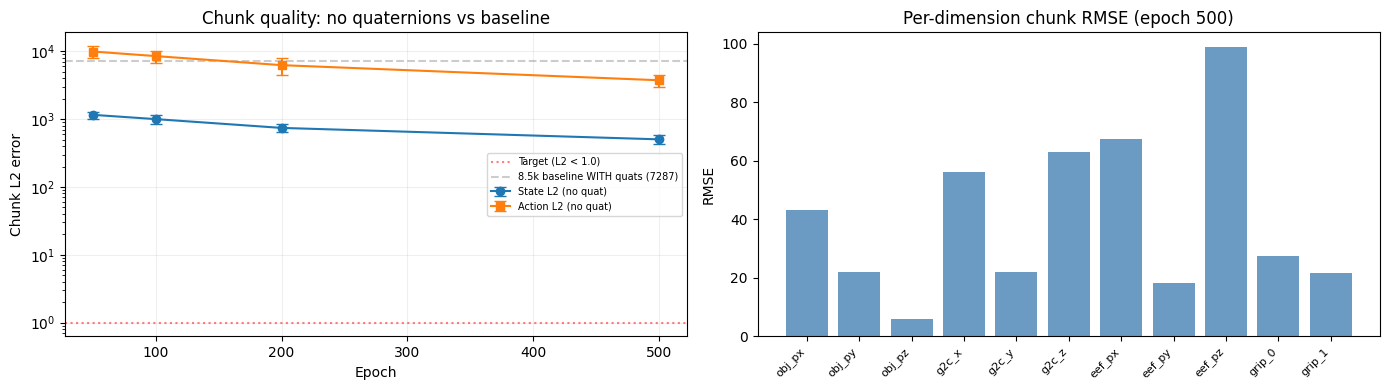


Final chunk L2 (states, no quat): 502.8833
8.5k baseline WITH quaternions:     7287
Improvement factor:                 14.5x
MARGINAL: Some improvement but quaternions were not the main problem.


In [13]:
# --- Chunk quality progression ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

epochs_list = sorted(chunk_results.keys())
state_l2s = [chunk_results[e]["state_l2"] for e in epochs_list]
action_l2s = [chunk_results[e]["action_l2"] for e in epochs_list]
state_stds = [chunk_results[e]["state_l2_std"] for e in epochs_list]
action_stds = [chunk_results[e]["action_l2_std"] for e in epochs_list]

ax = axes[0]
ax.errorbar(epochs_list, state_l2s, yerr=state_stds, marker="o", label="State L2 (no quat)", capsize=4)
ax.errorbar(epochs_list, action_l2s, yerr=action_stds, marker="s", label="Action L2 (no quat)", capsize=4)
ax.axhline(1.0, color="red", linestyle=":", alpha=0.5, label="Target (L2 < 1.0)")
ax.axhline(7287, color="gray", linestyle="--", alpha=0.4, label="8.5k baseline WITH quats (7287)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Chunk L2 error")
ax.set_title("Chunk quality: no quaternions vs baseline")
ax.legend(fontsize=7)
ax.set_yscale("log")
ax.grid(alpha=0.2)

# Per-dim RMSE
ax = axes[1]
final_rmse = chunk_results[epochs_list[-1]]["rmse_per_dim"]
ax.bar(range(len(final_rmse)), final_rmse, color="steelblue", alpha=0.8)
ax.set_xticks(range(len(DIM_LABELS)))
ax.set_xticklabels(DIM_LABELS, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("RMSE")
ax.set_title(f"Per-dimension chunk RMSE (epoch {epochs_list[-1]})")

plt.tight_layout()
plt.show()

final_l2 = chunk_results[epochs_list[-1]]["state_l2"]
print(f"\nFinal chunk L2 (states, no quat): {final_l2:.4f}")
print(f"8.5k baseline WITH quaternions:     7287")
print(f"Improvement factor:                 {7287 / max(final_l2, 1e-6):.1f}x")
if final_l2 < 1.0:
    print("PASS: Dropping quaternions fixed chunk quality!")
elif final_l2 < 100.0:
    print("IMPROVED: Much better, but still above target. Try more training or larger model.")
else:
    print("MARGINAL: Some improvement but quaternions were not the main problem.")

## Step 5: Generate Synthetic Trajectories via Stitching

In [16]:
NUM_TRAJS = 50
MAX_LENGTH = HORIZON

init_states = []
for i in range(NUM_TRAJS):
    traj_i = load_rollout_latents(rollout_paths[i % len(rollout_paths)])
    latents = traj_i.latents
    if latents.ndim == 3:
        latents = latents[:, 0, :]
    init_states.append(latents[0])

init_states_t = torch.tensor(np.stack(init_states), dtype=torch.float32)
print(f"Initial states shape: {init_states_t.shape}")  # (50, 11)

print(f"Generating {NUM_TRAJS} stitched trajectories (max {MAX_LENGTH} steps)...\n")

syn_states, syn_actions, end_indices = diffuser.generate_full_trajectory(
    initial_states=init_states_t,
    max_length=MAX_LENGTH,
    guided=False,
    verbose=False,
)

print(f"Generated {NUM_TRAJS} trajectories:")
print(f"  states shape: {syn_states.shape}")   # (50, 60, 11)
print(f"  actions shape: {syn_actions.shape}")  # (50, 60, 7)
print(f"  state range: [{syn_states.min():.2f}, {syn_states.max():.2f}]")
print(f"  action range: [{syn_actions.min():.2f}, {syn_actions.max():.2f}]")

Initial states shape: torch.Size([50, 11])
Generating 50 stitched trajectories (max 60 steps)...


                                                                                                    
1 / 256 [                                                            ]   0% | 175.4 Hz
t : 255
                                                                                                    
                                                                                                    
2 / 256 [                                                            ]   0% | 186.0 Hz
t : 254
                                                                                                    
                                                                                                    
3 / 256 [                                                            ]   1% | 190.0 Hz
t : 253
                                                                                                    
          

## Diagnostics: Per-Step MSE + Clamped Baseline

In [17]:
from src.latent_sope.eval.metrics import trajectory_reconstruction_mse

# Load real trajectories (already filtered to 11-dim)
real_states_list, real_actions_list, real_rewards_list = [], [], []
for i in range(NUM_TRAJS):
    traj_i = load_rollout_latents(rollout_paths[i % len(rollout_paths)])
    latents = traj_i.latents
    if latents.ndim == 3:
        latents = latents[:, 0, :]
    actions, rewards = traj_i.actions, traj_i.rewards
    T = latents.shape[0]
    if T >= MAX_LENGTH:
        real_states_list.append(latents[:MAX_LENGTH])
        real_actions_list.append(actions[:MAX_LENGTH])
        real_rewards_list.append(rewards[:MAX_LENGTH])
    else:
        real_states_list.append(np.pad(latents, ((0, MAX_LENGTH - T), (0, 0))))
        real_actions_list.append(np.pad(actions, ((0, MAX_LENGTH - T), (0, 0))))
        real_rewards_list.append(np.pad(rewards, (0, MAX_LENGTH - T)))

real_states = np.stack(real_states_list).astype(np.float32)
real_actions = np.stack(real_actions_list).astype(np.float32)
real_rewards = np.stack(real_rewards_list).astype(np.float32)

recon = trajectory_reconstruction_mse(real_states, syn_states, real_actions, syn_actions, end_indices)
print(f"Trajectory Reconstruction MSE ({recon.num_trajectories} trajs, {recon.trajectory_length} steps):")
print(f"  State MSE:  {recon.state_mse:.6f}")
print(f"  Action MSE: {recon.action_mse:.6f}")
print(f"\n  8.5k baseline WITH quats: state MSE = 1,175,015")

Trajectory Reconstruction MSE (50 trajs, 60 steps):
  State MSE:  35039.391030
  Action MSE: 4608945.590857

  8.5k baseline WITH quats: state MSE = 1,175,015


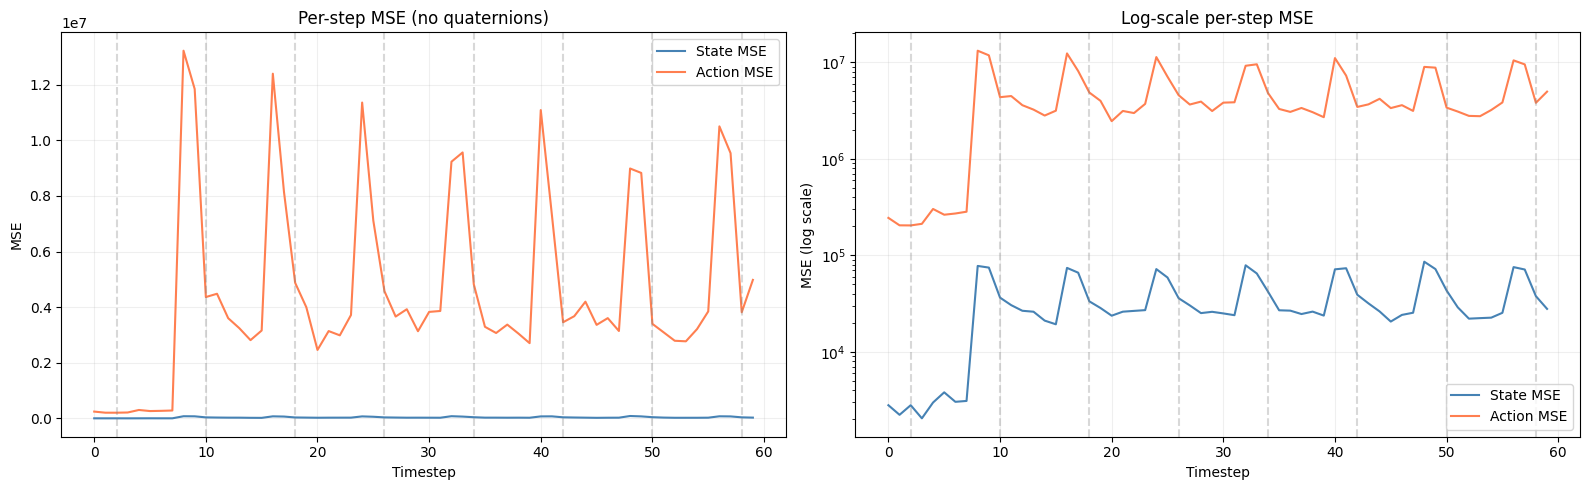

Error growth: 13.4x total over 7 chunks
  Per-chunk growth factor: 1.54x


In [18]:
# --- Per-step MSE with chunk boundaries ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(recon.state_mse_per_step, color="steelblue", linewidth=1.5, label="State MSE")
ax.plot(recon.action_mse_per_step, color="coral", linewidth=1.5, label="Action MSE")
chunk_size = diffusion_config.chunk_horizon
frame_stack = diffusion_config.frame_stack
for boundary in range(frame_stack, MAX_LENGTH, chunk_size):
    ax.axvline(boundary, color="gray", alpha=0.3, linestyle="--")
ax.set_xlabel("Timestep")
ax.set_ylabel("MSE")
ax.set_title("Per-step MSE (no quaternions)")
ax.legend()
ax.grid(alpha=0.2)

ax = axes[1]
state_mse_clipped = np.clip(recon.state_mse_per_step, 1e-10, None)
action_mse_clipped = np.clip(recon.action_mse_per_step, 1e-10, None)
ax.semilogy(state_mse_clipped, color="steelblue", linewidth=1.5, label="State MSE")
ax.semilogy(action_mse_clipped, color="coral", linewidth=1.5, label="Action MSE")
for boundary in range(frame_stack, MAX_LENGTH, chunk_size):
    ax.axvline(boundary, color="gray", alpha=0.3, linestyle="--")
ax.set_xlabel("Timestep")
ax.set_ylabel("MSE (log scale)")
ax.set_title("Log-scale per-step MSE")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

if len(recon.state_mse_per_step) > 10:
    first_chunk_mse = np.mean(recon.state_mse_per_step[:chunk_size])
    last_chunk_mse = np.mean(recon.state_mse_per_step[-chunk_size:])
    n_chunks = MAX_LENGTH // chunk_size
    if first_chunk_mse > 0:
        growth_factor = last_chunk_mse / first_chunk_mse
        per_chunk_growth = growth_factor ** (1.0 / max(n_chunks - 1, 1))
        print(f"Error growth: {growth_factor:.1f}x total over {n_chunks} chunks")
        print(f"  Per-chunk growth factor: {per_chunk_growth:.2f}x")

In [19]:
# --- Clamped baseline + OPE (direct reward computation, no encoder needed) ---
from src.latent_sope.eval.metrics import ope_eval

# Clamp
real_state_min = real_states.min(axis=(0, 1))
real_state_max = real_states.max(axis=(0, 1))
syn_states_clamped = np.clip(syn_states, real_state_min, real_state_max)
syn_actions_clamped = np.clip(syn_actions, real_actions.min(axis=(0,1)), real_actions.max(axis=(0,1)))

n_clamped = ((syn_states < real_state_min) | (syn_states > real_state_max)).sum()
print(f"State range: [{syn_states.min():.2f}, {syn_states.max():.2f}] -> clamped to [{syn_states_clamped.min():.2f}, {syn_states_clamped.max():.2f}]")
print(f"Clamped {n_clamped}/{syn_states.size} state values ({100*n_clamped/syn_states.size:.1f}%)")
print(f"  8.5k baseline WITH quats: 99.7% clamped")

# Compute rewards directly — cube z is at CUBE_Z_IDX in the reduced layout
SUCCESS_THRESHOLD = 0.84

def compute_returns(states, gamma=1.0):
    """Compute per-trajectory returns from cube z-position."""
    cube_z = states[:, :, CUBE_Z_IDX]  # (B, T)
    rewards = (cube_z > SUCCESS_THRESHOLD).astype(np.float32)
    if gamma >= 1.0:
        return rewards.sum(axis=1)  # (B,)
    discounts = gamma ** np.arange(rewards.shape[1])
    return (rewards * discounts[None, :]).sum(axis=1)

returns_unclamped = compute_returns(syn_states, gamma)
returns_clamped = compute_returns(syn_states_clamped, gamma)

ope_unclamped = ope_eval(oracle_value, returns_unclamped)
ope_clamped = ope_eval(oracle_value, returns_clamped)

real_success_rate = np.mean([float((real_states[i, :, CUBE_Z_IDX] > SUCCESS_THRESHOLD).any()) for i in range(NUM_TRAJS)])
syn_success_unclamped = np.mean([float((syn_states[i, :, CUBE_Z_IDX] > SUCCESS_THRESHOLD).any()) for i in range(NUM_TRAJS)])
syn_success_clamped = np.mean([float((syn_states_clamped[i, :, CUBE_Z_IDX] > SUCCESS_THRESHOLD).any()) for i in range(NUM_TRAJS)])

print(f"\n{'':30s} {'Unclamped':>12s} {'Clamped':>12s} {'Oracle':>12s}")
print("-" * 70)
print(f"{'OPE estimate':30s} {ope_unclamped.ope_estimate:12.3f} {ope_clamped.ope_estimate:12.3f} {oracle_value:12.3f}")
print(f"{'OPE std':30s} {ope_unclamped.ope_std:12.3f} {ope_clamped.ope_std:12.3f} {'':>12s}")
print(f"{'Relative error':30s} {ope_unclamped.relative_error:11.1%} {ope_clamped.relative_error:11.1%} {'':>12s}")
print(f"{'Success rate (real)':30s} {real_success_rate:11.1%}")
print(f"{'Success rate (unclamped)':30s} {syn_success_unclamped:11.1%}")
print(f"{'Success rate (clamped)':30s} {syn_success_clamped:11.1%}")
print(f"\n  8.5k baseline WITH quats: OPE = 29.340, rel error = 5333%, success = 100% (spurious)")

State range: [-1672.47, 1377.16] -> clamped to [-0.21, 1.04]
Clamped 32875/33000 state values (99.6%)
  8.5k baseline WITH quats: 99.7% clamped

                                  Unclamped      Clamped       Oracle
----------------------------------------------------------------------
OPE estimate                         26.160        0.000        0.540
OPE std                               4.154        0.000             
Relative error                     4744.4%      100.0%             
Success rate (real)                   0.0%
Success rate (unclamped)            100.0%
Success rate (clamped)                0.0%

  8.5k baseline WITH quats: OPE = 29.340, rel error = 5333%, success = 100% (spurious)


## Trajectory Sanity Checks

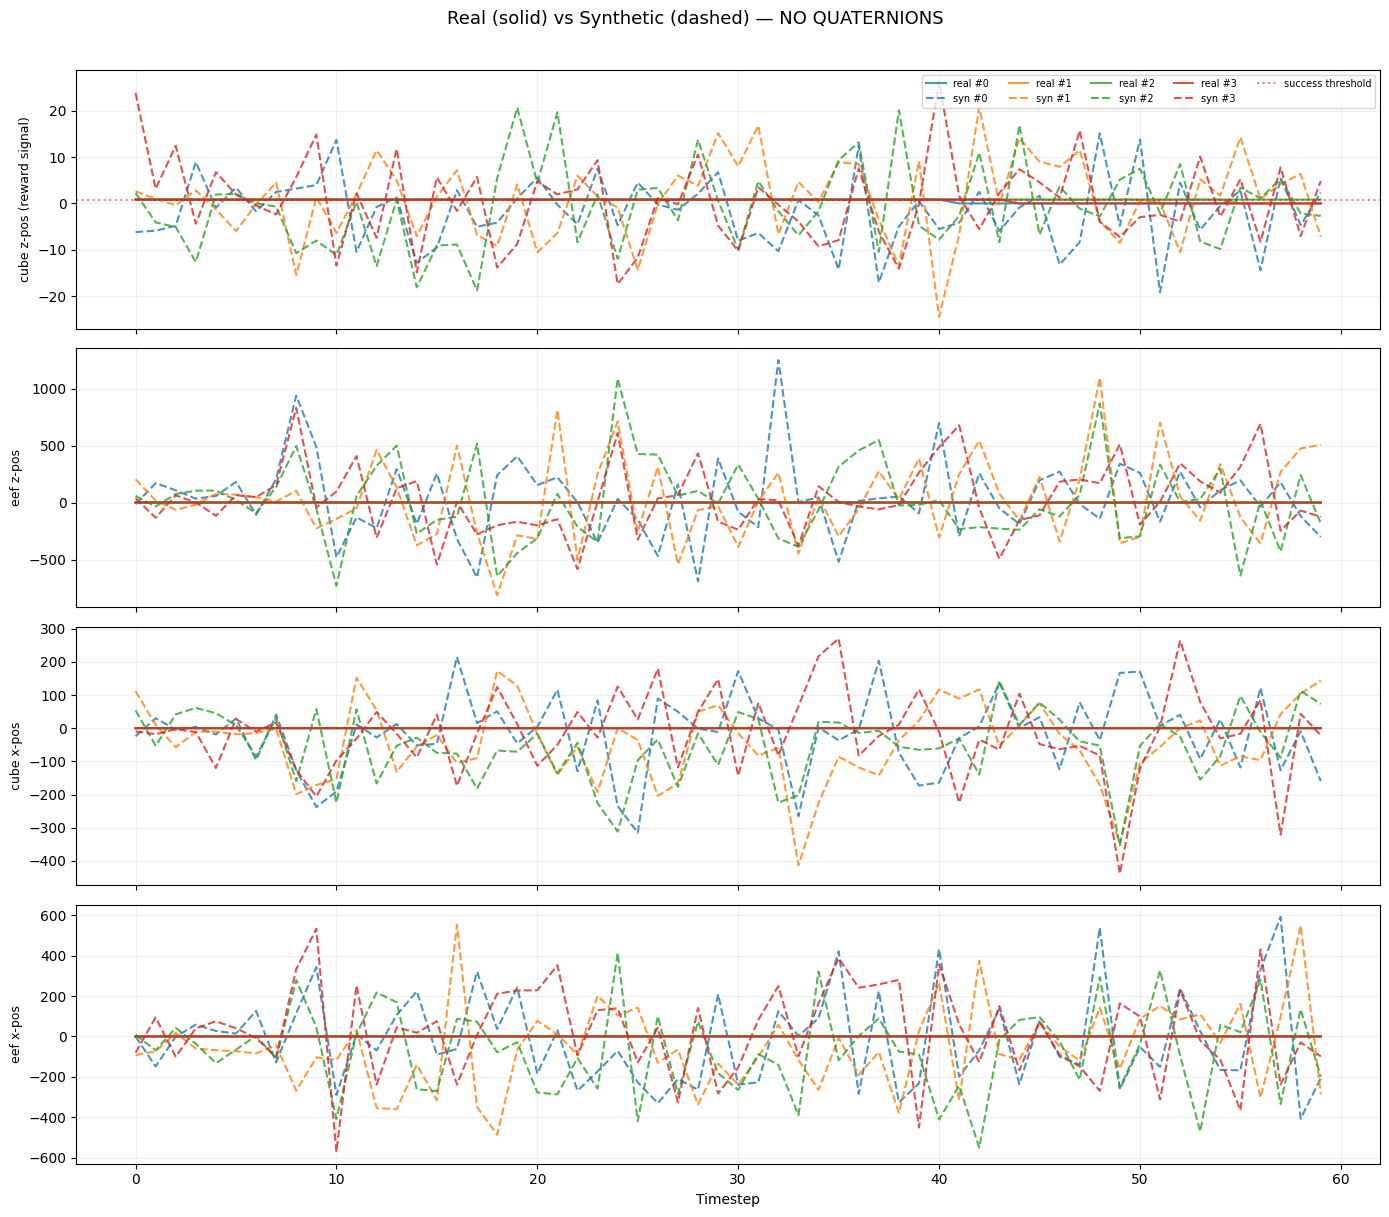

In [20]:
# --- Visual: real vs synthetic trajectories (key dims in reduced layout) ---
key_dims = [
    (CUBE_Z_IDX, "cube z-pos (reward signal)"),
    (EEF_Z_IDX, "eef z-pos"),
    (CUBE_X_IDX, "cube x-pos"),
    (EEF_X_IDX, "eef x-pos"),
]
n_show = min(4, NUM_TRAJS)

fig, axes = plt.subplots(len(key_dims), 1, figsize=(14, 3 * len(key_dims)), sharex=True)
for row, (dim_idx, dim_name) in enumerate(key_dims):
    ax = axes[row]
    for b in range(n_show):
        ax.plot(real_states[b, :, dim_idx], color=f"C{b}", alpha=0.8, linewidth=1.5,
                label=f"real #{b}" if row == 0 else None)
        ax.plot(syn_states[b, :, dim_idx], color=f"C{b}", alpha=0.8, linewidth=1.5,
                linestyle="--", label=f"syn #{b}" if row == 0 else None)
    ax.set_ylabel(dim_name, fontsize=9)
    if dim_idx == CUBE_Z_IDX:
        ax.axhline(SUCCESS_THRESHOLD, color="red", linestyle=":", alpha=0.5,
                   label="success threshold" if row == 0 else None)
    ax.grid(alpha=0.2)

axes[0].legend(ncol=n_show + 1, fontsize=7, loc="upper right")
axes[-1].set_xlabel("Timestep")
fig.suptitle("Real (solid) vs Synthetic (dashed) — NO QUATERNIONS", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

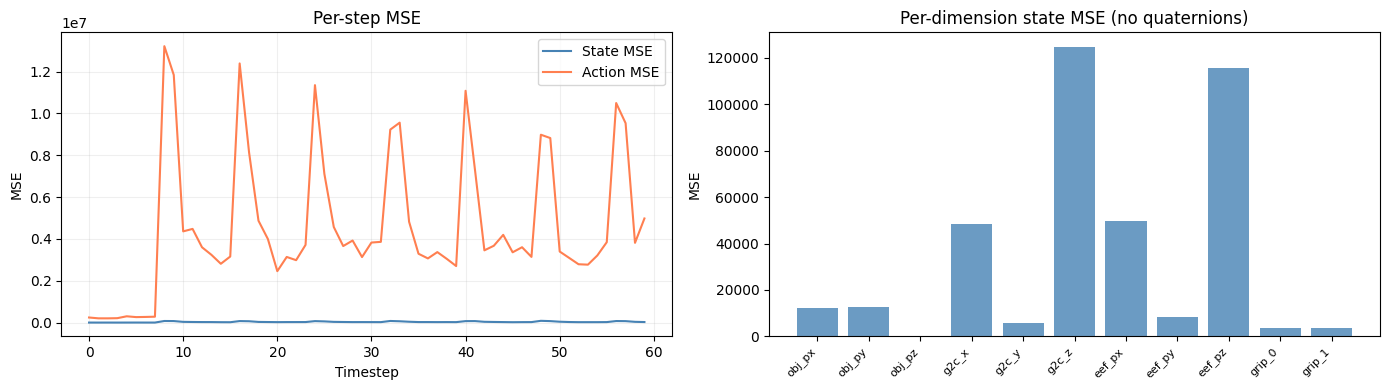


Dim         Real mean   Syn mean   Real std    Syn std       Real [min,max]        Syn [min,max]
------------------------------------------------------------------------------------------------------
obj_px         0.0037   -18.9341     0.0162   109.1189 [ -0.028,   0.040]  [-583.726, 393.949]
obj_py         0.0031    15.9606     0.0152   112.2481 [ -0.032,   0.029]  [-483.081, 460.387]
obj_pz         0.7323    -0.6303     0.2553     8.2552 [  0.000,   0.835]  [-31.560,  26.218]
g2c_x          0.0168     4.1525     0.0380   220.2360 [ -0.044,   0.140]  [-1121.149, 1087.294]
g2c_y          0.0019   -22.6011     0.0113    73.8707 [ -0.052,   0.049]  [-353.090, 282.597]
g2c_z         -0.0754    24.0531     0.0619   352.3883 [ -0.214,   0.010]  [-1672.468, 1346.353]
eef_px        -0.0131   -38.3796     0.0376   219.3729 [ -0.124,   0.067]  [-1056.939, 861.952]
eef_py         0.0012    -5.1035     0.0150    91.1827 [ -0.039,   0.042]  [-489.241, 370.489]
eef_pz         0.8077    18.8933   

In [21]:
# --- Per-dim MSE + marginal stats ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(recon.state_mse_per_step, color="steelblue", linewidth=1.5, label="State MSE")
ax1.plot(recon.action_mse_per_step, color="coral", linewidth=1.5, label="Action MSE")
ax1.set_xlabel("Timestep")
ax1.set_ylabel("MSE")
ax1.set_title("Per-step MSE")
ax1.legend()
ax1.grid(alpha=0.2)

ax2.bar(range(len(recon.state_mse_per_dim)), recon.state_mse_per_dim, color="steelblue", alpha=0.8)
ax2.set_xticks(range(len(DIM_LABELS)))
ax2.set_xticklabels(DIM_LABELS, rotation=45, ha="right", fontsize=8)
ax2.set_ylabel("MSE")
ax2.set_title("Per-dimension state MSE (no quaternions)")
plt.tight_layout()
plt.show()

# Marginal statistics
print(f"\n{'Dim':<10} {'Real mean':>10} {'Syn mean':>10} {'Real std':>10} {'Syn std':>10} {'Real [min,max]':>20} {'Syn [min,max]':>20}")
print("-" * 102)
for d, label in enumerate(DIM_LABELS):
    r, s = real_states[:, :, d], syn_states[:, :, d]
    print(f"{label:<10} {r.mean():10.4f} {s.mean():10.4f} {r.std():10.4f} {s.std():10.4f} "
          f"[{r.min():7.3f}, {r.max():7.3f}]  [{s.min():7.3f}, {s.max():7.3f}]")

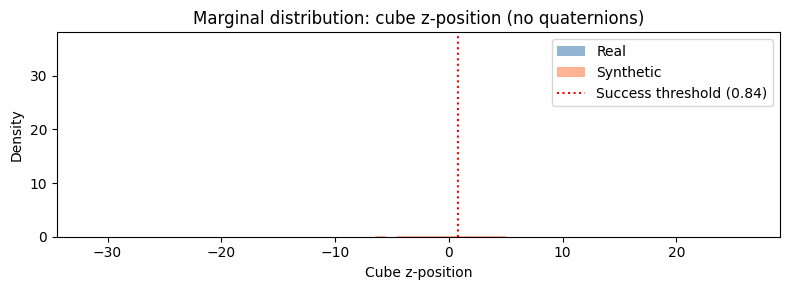

In [22]:
# --- Cube z histogram ---
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(real_states[:, :, CUBE_Z_IDX].ravel(), bins=60, alpha=0.6, density=True, label="Real", color="steelblue")
ax.hist(syn_states[:, :, CUBE_Z_IDX].ravel(), bins=60, alpha=0.6, density=True, label="Synthetic", color="coral")
ax.axvline(SUCCESS_THRESHOLD, color="red", linestyle=":", label=f"Success threshold ({SUCCESS_THRESHOLD})")
ax.set_xlabel("Cube z-position")
ax.set_ylabel("Density")
ax.set_title("Marginal distribution: cube z-position (no quaternions)")
ax.legend()
plt.tight_layout()
plt.show()

## OPE Summary

OPE Evaluation — 8.5k steps, NO QUATERNIONS
  Oracle V^pi:           0.540
  OPE estimate:          26.160 (std=4.154)
  OPE clamped:           0.000 (std=0.000)
  Relative error:        4744.44%
  Clamped rel. error:    100.00%


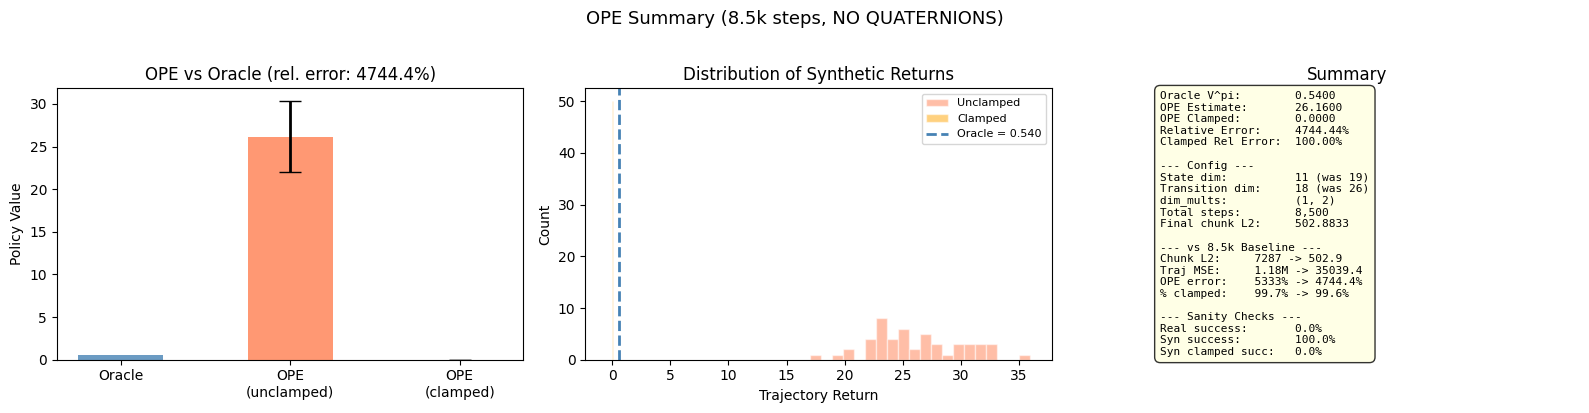

In [23]:
result = ope_unclamped
final_l2 = chunk_results[sorted(chunk_results.keys())[-1]]["state_l2"]

print("=" * 60)
print("OPE Evaluation — 8.5k steps, NO QUATERNIONS")
print("=" * 60)
print(f"  Oracle V^pi:           {result.oracle_value:.3f}")
print(f"  OPE estimate:          {result.ope_estimate:.3f} (std={result.ope_std:.3f})")
print(f"  OPE clamped:           {ope_clamped.ope_estimate:.3f} (std={ope_clamped.ope_std:.3f})")
print(f"  Relative error:        {result.relative_error:.2%}")
print(f"  Clamped rel. error:    {ope_clamped.relative_error:.2%}")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.bar(
    ["Oracle", "OPE\n(unclamped)", "OPE\n(clamped)"],
    [result.oracle_value, result.ope_estimate, ope_clamped.ope_estimate],
    color=["steelblue", "coral", "orange"], alpha=0.8, width=0.5,
)
ax.errorbar(1, result.ope_estimate, yerr=result.ope_std, fmt="none", color="black", capsize=8, linewidth=2)
ax.errorbar(2, ope_clamped.ope_estimate, yerr=ope_clamped.ope_std, fmt="none", color="black", capsize=8, linewidth=2)
ax.set_ylabel("Policy Value")
ax.set_title(f"OPE vs Oracle (rel. error: {result.relative_error:.1%})")

ax = axes[1]
ax.hist(returns_unclamped, bins=20, alpha=0.5, color="coral", edgecolor="white", label="Unclamped")
ax.hist(returns_clamped, bins=20, alpha=0.5, color="orange", edgecolor="white", label="Clamped")
ax.axvline(result.oracle_value, color="steelblue", linewidth=2, linestyle="--", label=f"Oracle = {result.oracle_value:.3f}")
ax.set_xlabel("Trajectory Return")
ax.set_ylabel("Count")
ax.set_title("Distribution of Synthetic Returns")
ax.legend(fontsize=8)

ax = axes[2]
ax.axis("off")
summary = (
    f"Oracle V^pi:        {result.oracle_value:.4f}\n"
    f"OPE Estimate:       {result.ope_estimate:.4f}\n"
    f"OPE Clamped:        {ope_clamped.ope_estimate:.4f}\n"
    f"Relative Error:     {result.relative_error:.2%}\n"
    f"Clamped Rel Error:  {ope_clamped.relative_error:.2%}\n"
    f"\n--- Config ---\n"
    f"State dim:          {REDUCED_STATE_DIM} (was 19)\n"
    f"Transition dim:     {REDUCED_STATE_DIM + 7} (was 26)\n"
    f"dim_mults:          (1, 2)\n"
    f"Total steps:        {len(all_losses):,}\n"
    f"Final chunk L2:     {final_l2:.4f}\n"
    f"\n--- vs 8.5k Baseline ---\n"
    f"Chunk L2:     7287 -> {final_l2:.1f}\n"
    f"Traj MSE:     1.18M -> {recon.state_mse:.1f}\n"
    f"OPE error:    5333% -> {result.relative_error:.1%}\n"
    f"% clamped:    99.7% -> {100*n_clamped/syn_states.size:.1f}%\n"
    f"\n--- Sanity Checks ---\n"
    f"Real success:       {real_success_rate:.1%}\n"
    f"Syn success:        {syn_success_unclamped:.1%}\n"
    f"Syn clamped succ:   {syn_success_clamped:.1%}"
)
ax.text(0.1, 0.5, summary, transform=ax.transAxes, fontsize=8,
        verticalalignment="center", fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", alpha=0.8))
ax.set_title("Summary")

fig.suptitle("OPE Summary (8.5k steps, NO QUATERNIONS)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Conclusions

Fill in after running:

**Comparison to 8.5k baseline (WITH quaternions):**

| Metric | With Quats (19-dim) | No Quats (11-dim) |
|--------|--------------------|-----------|
| Chunk L2 | 7287 | ? |
| Trajectory state MSE | 1,175,015 | ? |
| OPE relative error | 5333% | ? |
| % values clamped | 99.7% | ? |
| Success rate (unclamped) | 100% (spurious) | ? |

**Interpretation:**
- If chunk L2 drops dramatically (e.g., < 100): quaternions were a major problem.
  Next: try no-quat + larger model + 500k steps.
- If chunk L2 is similar (~7000): quaternions are NOT the issue.
  Next: focus on model capacity and training budget.
- If chunk L2 < 1.0: the 11-dim space is easy enough for even this small model.
  Next: proceed directly to 500k no-quat run with stitching.